# Week 09 Seminar

## Chapter 9. Support Vector Machines (SVM)

### Course: Machine Learning, 2025/2026, HSE
### Author: Maria Tikhonova, Teaching Team.

**Revised by:** Aleksandr Khizhik

---

**Learning objectives**
- Understand hard vs. soft margins and why SVMs maximize margin.
- Implement a tiny max-margin classifier and a soft-margin SVM from scratch.


## Importing libraries


In [ ]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import classification_report, recall_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC

# Plotting defaults
sns.set_theme()
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True

# Reproducibility
RNG = np.random.default_rng(42)

# Maximal Margin Classifier (hard margin)

For binary labels $y_i \in \{-1, +1\}$, a separating hyperplane is $f(\mathbf{x})=\mathbf{w}^\top \mathbf{x}+b$.
The **functional margin** of point $i$ is $M_i = y_i(\mathbf{w}^\top \mathbf{x}_i + b)$.

The **hard-margin** optimization maximizes the minimum margin subject to perfect separation. Equivalently:

$$
\min_{\mathbf{w}, b} \;\frac{1}{2}\lVert \mathbf{w}\rVert^2 \quad
\text{s.t. } y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 \;\; \forall i.
$$

The geometric margin (band half-width) is $1/\lVert\mathbf{w}\rVert$; the full margin is $2/\lVert\mathbf{w}\rVert$.


## Loading data

We'll use the [Iris](https://en.wikipedia.org/wiki/Iris_flower_data_set) dataset. It has 150 samples, 3 classes, and 4 numeric features:
sepal length/width (cm), petal length/width (cm).

In [ ]:
iris = load_iris()

X_full: np.ndarray = iris.data
y_full: np.ndarray = iris.target

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [ ]:
df = pd.DataFrame(X_full, columns=iris.feature_names)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


Basic summary:

In [ ]:
df.describe().round(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


## Binary setup for intuition

For the better illustration of how support vector machines work, let us project our data on a 2D plane. We use [PCA](https://en.wikipedia.org/wiki/Principal_component_analysis) method, which we will discuss the next week (so do not miss the future seminar ;)

As long as for maximal margin classifier we need a binary classification problem. We'll create a binary target:
- class **-1**: *setosa* (label 0)
- class **+1**: *versicolor* or *virginica* (labels 1 or 2)

In [ ]:
# Binary labels: setosa -> -1, others -> +1
y_bin = np.where(y_full == 0, -1, 1)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_bin, test_size=0.4, stratify=y_bin, random_state=42
)

print("Train shape:", X_train_raw.shape, " Test shape:", X_test_raw.shape)

Train shape: (90, 4)  Test shape: (60, 4)


In [ ]:
pca_viz = PCA(n_components=2, random_state=42)
X_train_2d = pca_viz.fit_transform(X_train_raw)
X_test_2d = pca_viz.transform(X_test_raw)

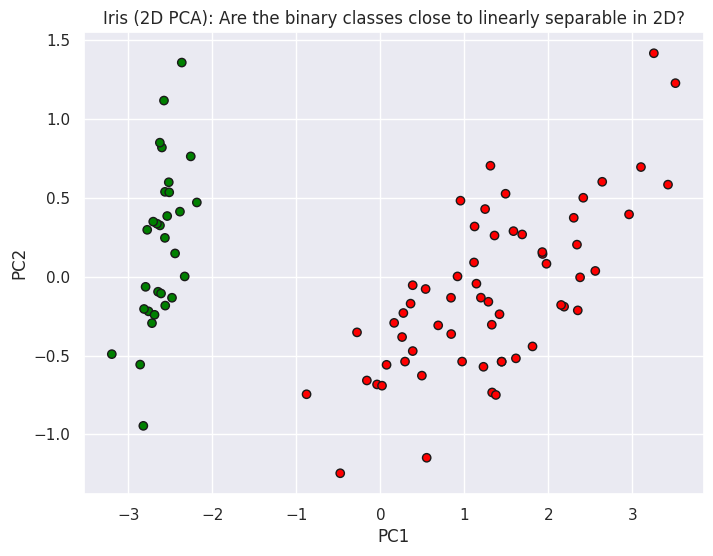

In [ ]:
# Quick look: are the binary classes close to linearly separable in 2D?
colors_bin = {-1: "green", 1: "red"}
plt.title("Iris (2D PCA): Are the binary classes close to linearly separable in 2D?")
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=[colors_bin[i] for i in y_train], edgecolor="k")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

# Loss functions vs. margin

In training, we want to penalize only the observations on the wrong side of the margin. Common surrogates for the 0–1 loss:
- **Hinge:** $\max(0, 1-M)$
- **Logistic:** $\log(1 + e^{-M})$

Below we visualize them.

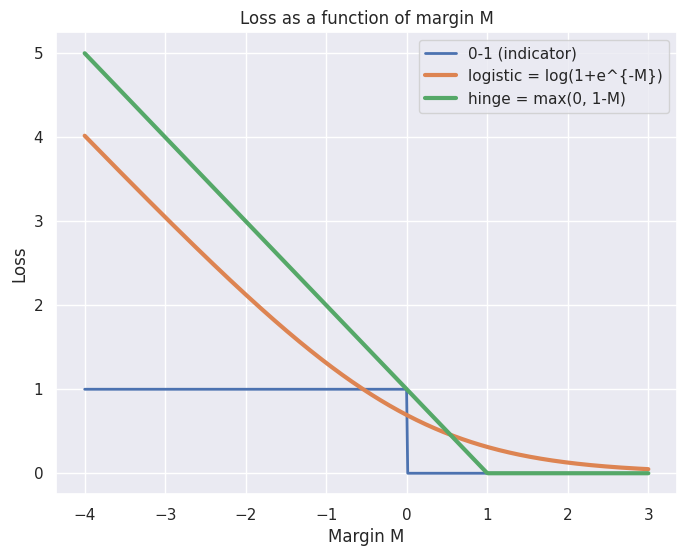

In [ ]:
xx = np.linspace(-4, 3, 500)

zero_one = (xx < 0).astype(float)
logistic = np.logaddexp(0.0, -xx)  # numerically stable log(1 + exp(-x))
hinge = np.maximum(0.0, 1.0 - xx)

plt.plot(xx, zero_one, label="0-1 (indicator)", linewidth=2)
plt.plot(xx, logistic, label="logistic = log(1+e^{-M})", linewidth=3)
plt.plot(xx, hinge, label="hinge = max(0, 1-M)", linewidth=3)
plt.title("Loss as a function of margin M")
plt.legend(); plt.xlabel("Margin M"); plt.ylabel("Loss"); plt.show()

# Implementing our own Maximal Margin Classifier

A minimalist SGD-style hard-margin learner is not numerically robust, but it's excellent for *intuition*.

In [ ]:
def add_bias_feature(a: np.ndarray) -> np.ndarray:
    """Append a bias=1 column to features."""
    return np.c_[a, np.ones(len(a))]

def hinge_loss_vec(margin: np.ndarray) -> np.ndarray:
    """Vectorized hinge loss for margins M."""
    return np.maximum(0.0, 1.0 - margin)

@dataclass
class MaximalMarginClassifier:
    """Didactic hard-margin-style perceptron with hinge updates (no slack).
    Note: Works only when data are (almost) separable in the chosen space.
    """
    lr: float = 5e-3
    alpha: float = 6e-3     # small L2 to keep weights bounded
    epochs: int = 150
    random_state: int = 42

    def fit(self, X_train: np.ndarray, y_train: np.ndarray,
            X_val: np.ndarray | None = None, y_val: np.ndarray | None = None,
            verbose: bool = False):
        if set(np.unique(y_train)) != {-1, 1}:
            raise ValueError("y must be in {-1, +1}")

        Xb_tr = add_bias_feature(X_train)
        if X_val is not None:
            Xb_val = add_bias_feature(X_val)

        rng = np.random.default_rng(self.random_state)
        self.w_ = rng.normal(0, 0.05, Xb_tr.shape[1])

        self.history_w_ = []
        self.train_loss_, self.val_loss_ = [], []

        for epoch in range(self.epochs):
            for i in rng.permutation(len(Xb_tr)):
                x_i, y_i = Xb_tr[i], y_train[i]
                margin = y_i * np.dot(self.w_, x_i)
                # gradient of hinge + 0.5*alpha*||w||^2
                if margin < 1.0:
                    grad = -y_i * x_i + self.alpha * self.w_
                else:
                    grad = self.alpha * self.w_
                self.w_ -= self.lr * grad
                self.history_w_.append(self.w_.copy())

            # tracking (mean hinge loss)
            tr_margin = y_train * (Xb_tr @ self.w_)
            tr_loss = hinge_loss_vec(tr_margin).mean()
            self.train_loss_.append(tr_loss)

            if X_val is not None:
                val_margin = y_val * (Xb_val @ self.w_)
                val_loss = hinge_loss_vec(val_margin).mean()
                self.val_loss_.append(val_loss)

            if verbose and (epoch % 25 == 0 or epoch == self.epochs - 1):
                msg = f"Epoch {epoch:3d} | train hinge {tr_loss:.4f}"
                if X_val is not None:
                    msg += f" | val hinge {val_loss:.4f}"
                print(msg)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        Xb = add_bias_feature(X)
        s = Xb @ self.w_
        return np.where(s >= 0.0, 1, -1)

**Train and visualize**

Weights for w0*x + w1*y + b = 0
[ 0.91354566 -0.52313482  1.07591144]


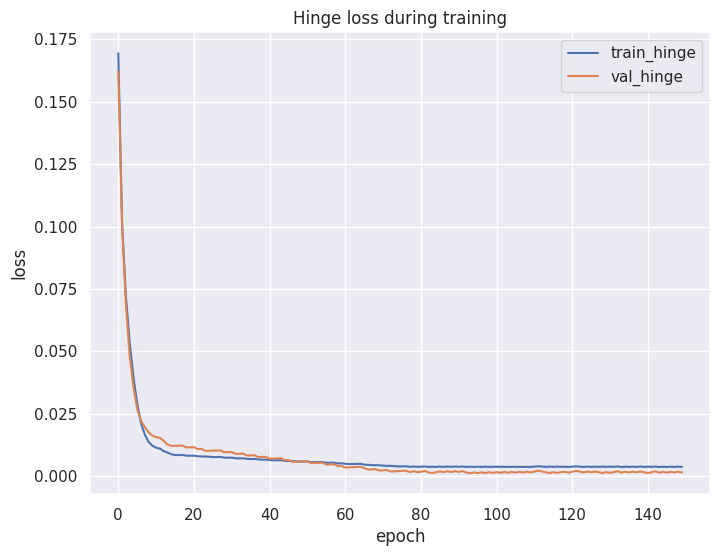

In [ ]:
mmc = MaximalMarginClassifier(lr=5e-3, alpha=6e-3, epochs=150, random_state=42)
mmc.fit(X_train_2d, y_train, X_test_2d, y_test, verbose=False)

print("Weights for w0*x + w1*y + b = 0")
print(mmc.w_)

plt.plot(mmc.train_loss_, label="train_hinge")
if len(mmc.val_loss_) > 0:
    plt.plot(mmc.val_loss_, label="val_hinge")
plt.legend(); plt.title("Hinge loss during training"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()

**Visualize hyperplane and ±1 margins for the *didactic* classifier.**

We draw the decision boundary and margins as the level sets

- decision boundary:  $w_0 x + w_1 y + b = 0$
- margins:            $w_0 x + w_1 y + b = \pm 1$

This definition also works when the separator is vertical ($w_1 \approx 0$).

In [ ]:
def plot_hyperplane_and_margins(ax, w: np.ndarray, b: float, xlim, ylim, label="hyperplane"):
    """Plot decision boundary w·x + b = 0 and true margins w·x + b = ±1.
    Handles vertical separators (w1≈0) and degenerate w via EPS.
    """
    w0, w1 = w
    EPS = 1e-12
    # Degenerate guard
    if np.hypot(w0, w1) < EPS:
        ax.set_title((ax.get_title() or "") + " (degenerate w)")
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        return

    if np.abs(w1) > EPS:
        xs = np.linspace(xlim[0], xlim[1], 400)
        y0 = -(w0/w1)*xs - b/w1            # w0*x + w1*y + b = 0
        y_plus  = -(w0/w1)*xs - (b+1.0)/w1 # w0*x + w1*y + b = +1
        y_minus = -(w0/w1)*xs - (b-1.0)/w1 # w0*x + w1*y + b = -1
        ax.plot(xs, y0, lw=2, label=label)
        ax.plot(xs, y_plus,  "--", label="margin +1")
        ax.plot(xs, y_minus, "--", label="margin -1")
    else:
        # Vertical family: w0*x + b = {0, +1, -1}
        x0     = -(b)/w0
        x_plus = -(b+1.0)/w0
        x_minus= -(b-1.0)/w0
        ax.axvline(x0, lw=2, label=label)
        ax.axvline(x_plus,  ls="--", label="margin +1")
        ax.axvline(x_minus, ls="--", label="margin -1")
    ax.set_xlim(xlim); ax.set_ylim(ylim)

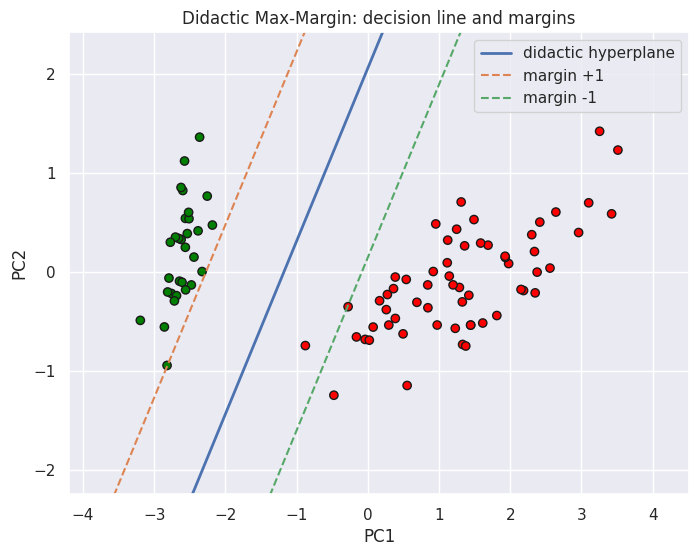

In [ ]:
w0, w1, b = mmc.w_
w_vec = np.array([w0, w1])

ax = plt.gca()
ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=[colors_bin[i] for i in y_train], edgecolor="k")
xlim = (X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1)
ylim = (X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1)
plot_hyperplane_and_margins(ax, w_vec, b, xlim, ylim, label="didactic hyperplane")
ax.set_title("Didactic Max-Margin: decision line and margins")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend()
plt.show()

**Test-set performance (didactic model)**

Number of errors on test set: 0


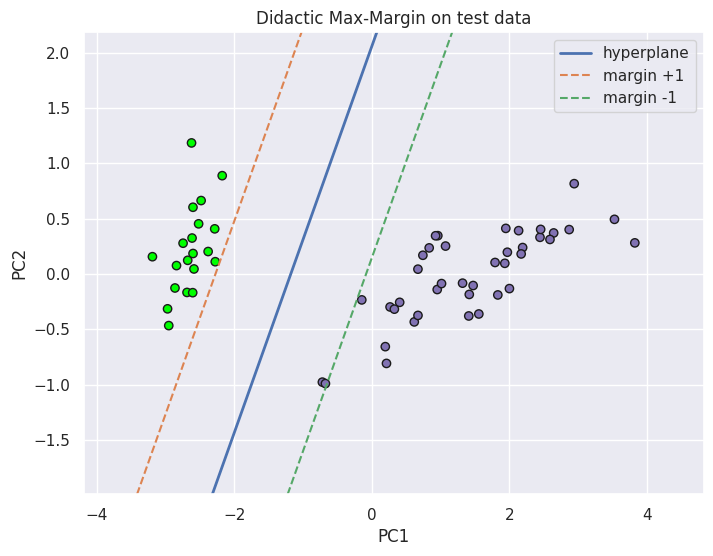

In [ ]:
y_pred = mmc.predict(X_test_2d)
num_errors = int(np.sum(y_pred != y_test))
print("Number of errors on test set:", num_errors)

disp_colors = np.where(y_pred != y_test, "black", np.where(y_pred == 1, "m", "lime"))
ax = plt.gca()
ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=disp_colors, edgecolor="k")
plot_hyperplane_and_margins(
    ax, w_vec, b,
    (X_test_2d[:,0].min()-1, X_test_2d[:,0].max()+1),
    (X_test_2d[:,1].min()-1, X_test_2d[:,1].max()+1),
    label="hyperplane"
)
ax.set_title("Didactic Max-Margin on test data")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(); plt.show()

Perfect result! No mistakes as long as our data was lineary separable.

# The non-separable case (soft margin)

When no separating hyperplane exists, we introduce **slack**:
$$
\min_{\mathbf{w},b,\xi} \frac{1}{2}\lVert \mathbf{w}\rVert^2 + C\sum_i \xi_i
\quad \text{s.t. } y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 - \xi_i,\; \xi_i \ge 0.
$$
Larger $C$ reduces violations (harder margin).

**Setup:** join *setosa* and *versicolor* as $-1$ vs. *virginica* as $+1$, which is **not** linearly separable in 2D.

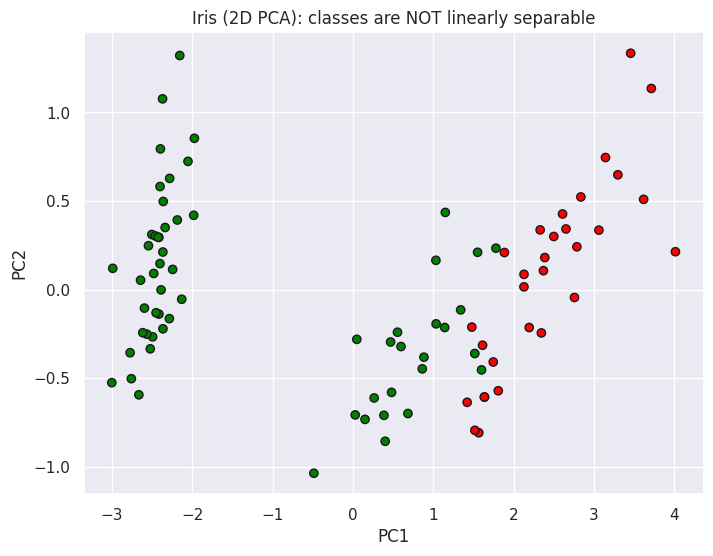

In [ ]:
# data preparation (new labels)
y_ns = np.where(iris.target == 2, 1, -1)  # virginica vs others
Xtr_raw_ns, Xte_raw_ns, ytr_ns, yte_ns = train_test_split(
    X_full, y_ns, test_size=0.4, stratify=y_ns, random_state=42
)

pca_viz_ns = PCA(n_components=2, random_state=42)
Xtr_ns_2d = pca_viz_ns.fit_transform(Xtr_raw_ns)
Xte_ns_2d = pca_viz_ns.transform(Xte_raw_ns)

plt.title("Iris (2D PCA): classes are NOT linearly separable")
plt.scatter(Xtr_ns_2d[:, 0], Xtr_ns_2d[:, 1], c=[colors_bin[i] for i in ytr_ns], edgecolor="k")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

# Soft-Margin SVM (didactic implementation)

We optimize hinge loss + L2 regularization via simple SGD steps.

Weights for w0*x + w1*y + b = 0
[ 3.5000079  -2.99324717 -5.93263132]


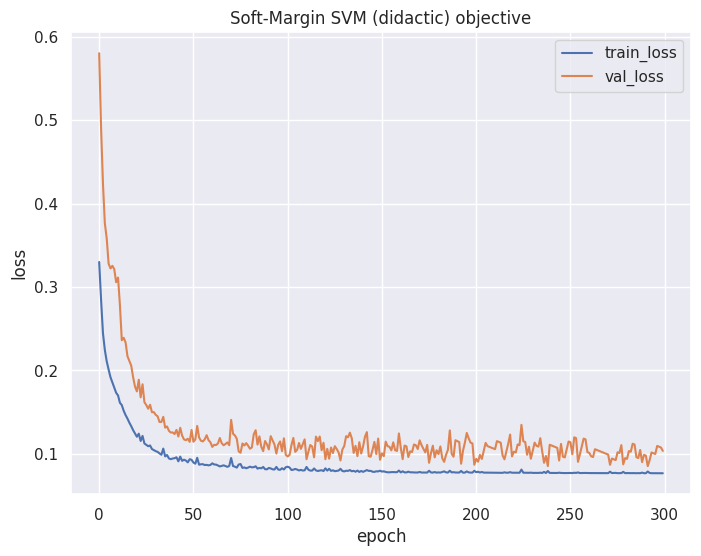

In [ ]:
@dataclass
class CustomSVM:
    lr: float = 3e-2
    alpha: float = 1e-4       # L2 regularization strength
    epochs: int = 300
    random_state: int = 42

    def fit(self, X_train: np.ndarray, y_train: np.ndarray,
            X_val: np.ndarray | None = None, y_val: np.ndarray | None = None):
        if set(np.unique(y_train)) != {-1, 1}:
            raise ValueError("y must be in {-1, +1}")

        Xb_tr = add_bias_feature(X_train)
        Xb_val = add_bias_feature(X_val) if X_val is not None else None

        rng = np.random.default_rng(self.random_state)
        self.w_ = rng.normal(0, 0.05, Xb_tr.shape[1])

        self.train_loss_, self.val_loss_ = [], []

        for epoch in range(self.epochs):
            for i in rng.permutation(len(Xb_tr)):
                x_i, y_i = Xb_tr[i], y_train[i]
                margin = y_i * np.dot(self.w_, x_i)
                if margin < 1.0:
                    grad = -y_i * x_i + self.alpha * self.w_
                else:
                    grad = self.alpha * self.w_
                self.w_ -= self.lr * grad

            # track mean soft-margin objective (hinge + L2)
            tr_margin = y_train * (Xb_tr @ self.w_)
            tr_hinge = hinge_loss_vec(tr_margin).mean()
            tr_reg = 0.5 * self.alpha * np.dot(self.w_, self.w_)
            self.train_loss_.append(tr_hinge + tr_reg)

            if Xb_val is not None:
                val_margin = y_val * (Xb_val @ self.w_)
                val_hinge = hinge_loss_vec(val_margin).mean()
                val_reg = 0.5 * self.alpha * np.dot(self.w_, self.w_)
                self.val_loss_.append(val_hinge + val_reg)

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        Xb = add_bias_feature(X)
        s = Xb @ self.w_
        return np.where(s >= 0.0, 1, -1)

# Train and visualize
svm_didactic = CustomSVM(lr=3e-2, alpha=1e-4, epochs=300, random_state=42).fit(
    Xtr_ns_2d, ytr_ns, Xte_ns_2d, yte_ns
)

print("Weights for w0*x + w1*y + b = 0")
print(svm_didactic.w_)

plt.plot(svm_didactic.train_loss_, label="train_loss")
if len(svm_didactic.val_loss_) > 0:
    plt.plot(svm_didactic.val_loss_, label="val_loss")
plt.legend(); plt.title("Soft-Margin SVM (didactic) objective"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.show()

**Training visualization (non-separable)**

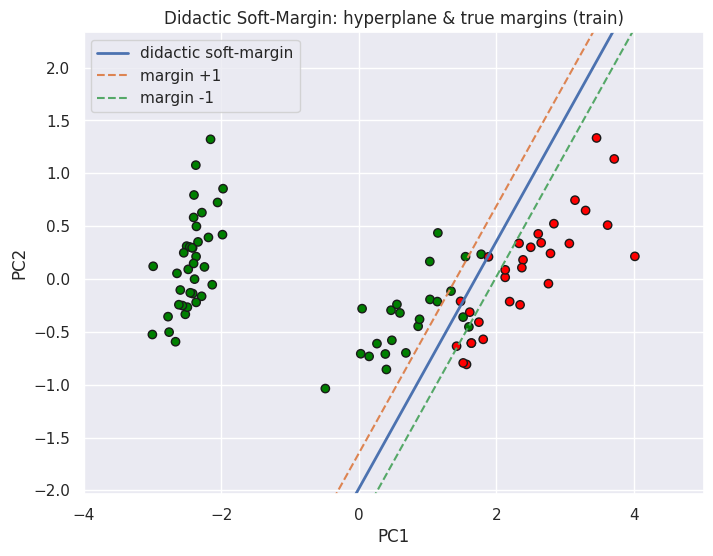

In [ ]:
ax = plt.gca()
ax.scatter(Xtr_ns_2d[:, 0], Xtr_ns_2d[:, 1], c=[colors_bin[i] for i in ytr_ns], edgecolor="k")
w0, w1, b = svm_didactic.w_
plot_hyperplane_and_margins(ax, np.array([w0, w1]), b,
                            (Xtr_ns_2d[:,0].min()-1, Xtr_ns_2d[:,0].max()+1),
                            (Xtr_ns_2d[:,1].min()-1, Xtr_ns_2d[:,1].max()+1),
                            label="didactic soft-margin")
ax.set_title("Didactic Soft-Margin: hyperplane & true margins (train)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(); plt.show()

**Test-set performance (didactic soft-margin)**

Number of errors on test (didactic soft-margin): 2


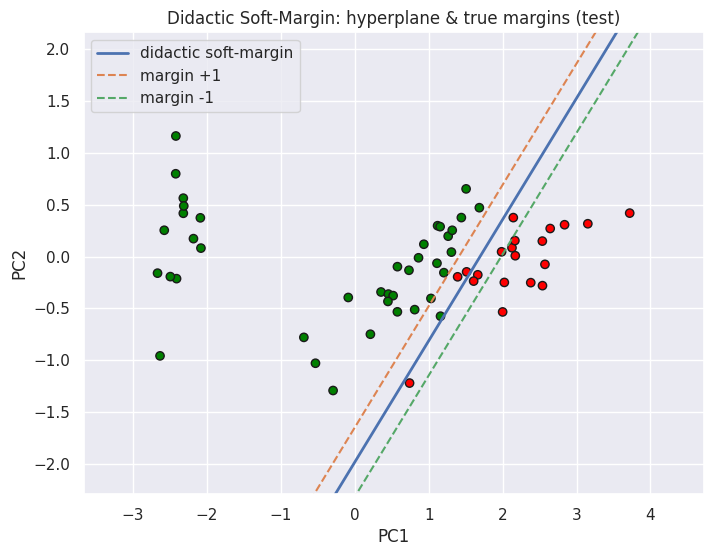

In [ ]:
y_pred_ns = svm_didactic.predict(Xte_ns_2d)
num_err_ns = int(np.sum(y_pred_ns != yte_ns))
print("Number of errors on test (didactic soft-margin):", int(np.sum(y_pred_ns != yte_ns)))

ax = plt.gca()
ax.scatter(Xte_ns_2d[:, 0], Xte_ns_2d[:, 1], c=[colors_bin[i] for i in yte_ns], edgecolor="k")
w0, w1, b = svm_didactic.w_
plot_hyperplane_and_margins(ax, np.array([w0, w1]), b,
                            (Xte_ns_2d[:,0].min()-1, Xte_ns_2d[:,0].max()+1),
                            (Xte_ns_2d[:,1].min()-1, Xte_ns_2d[:,1].max()+1),
                            label="didactic soft-margin")
ax.set_title("Didactic Soft-Margin: hyperplane & true margins (test)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(); plt.show()

As long as the data is not linearly separable we could not avoid mistakes even on the train set, however, their number is small (only 2).

# Scikit-learn implementation

In [ ]:
pipe_lin_full = make_pipeline(
    StandardScaler(),
    PCA(n_components=2, random_state=42),
    SVC(kernel="linear", C=1, random_state=42)
)
pipe_lin_full.fit(X_train_raw, y_train)
y_lin_full = pipe_lin_full.predict(X_test_raw)
print("Linear SVC pipeline metrics (binary, separable):")
print(classification_report(y_test, y_lin_full, digits=4))

Linear SVC pipeline metrics (binary, separable):
              precision    recall  f1-score   support

          -1     1.0000    1.0000    1.0000        20
           1     1.0000    1.0000    1.0000        40

    accuracy                         1.0000        60
   macro avg     1.0000    1.0000    1.0000        60
weighted avg     1.0000    1.0000    1.0000        60



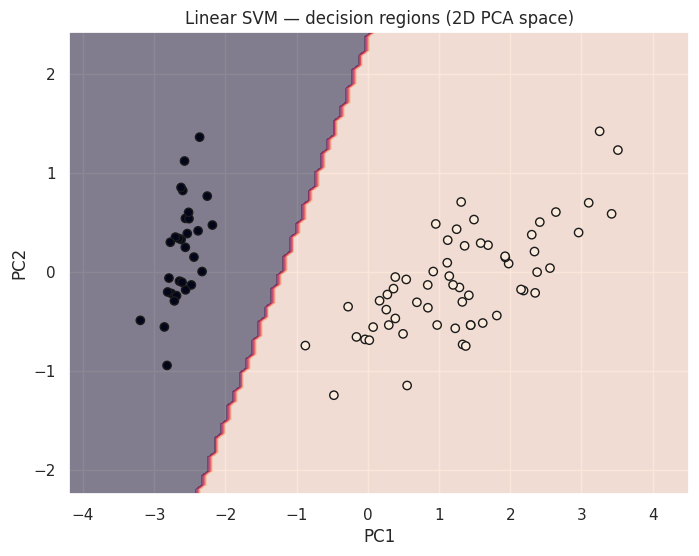

In [ ]:
# 2D plotting estimator on train-only PCA space
plot_lin_2d = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=1, random_state=42)
).fit(X_train_2d, y_train)

ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(plot_lin_2d, X_train_2d, response_method="predict", alpha=0.5, ax=ax)
ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor="k")
ax.set_title("Linear SVM — decision regions (2D PCA space)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.show()

# Support Vector Machines (non-linear)

If the boundary is non-linear, enlarge the feature space via kernels.
We'll re-label to make a tougher boundary: *versicolor* (+1) vs. (setosa, virginica) (-1).

In [ ]:
# Relabel
y_nl = np.where(iris.target == 1, 1, -1)  # versicolor vs others

Xtr_nl, Xte_nl, ytr_nl, yte_nl = train_test_split(
    X_full, y_nl, test_size=0.4, stratify=y_nl, random_state=42
)

print("Train shape:", Xtr_nl.shape, " Test shape:", Xte_nl.shape)

Train shape: (90, 4)  Test shape: (60, 4)


In [ ]:
# Train-only PCA for visualization
pca_viz_nl = PCA(n_components=2, random_state=42)
Xtr_nl_2d = pca_viz_nl.fit_transform(Xtr_nl)
Xte_nl_2d = pca_viz_nl.transform(Xte_nl)

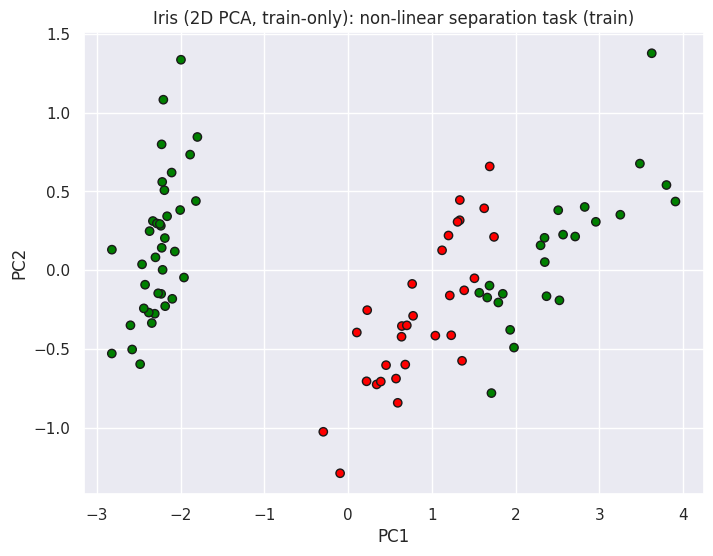

In [ ]:
plt.title("Iris (2D PCA, train-only): non-linear separation task (train)")
plt.scatter(Xtr_nl_2d[:, 0], Xtr_nl_2d[:, 1], c=[colors_bin[i] for i in ytr_nl], edgecolor="k")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

Non-linear task — Linear kernel recall: 0.35


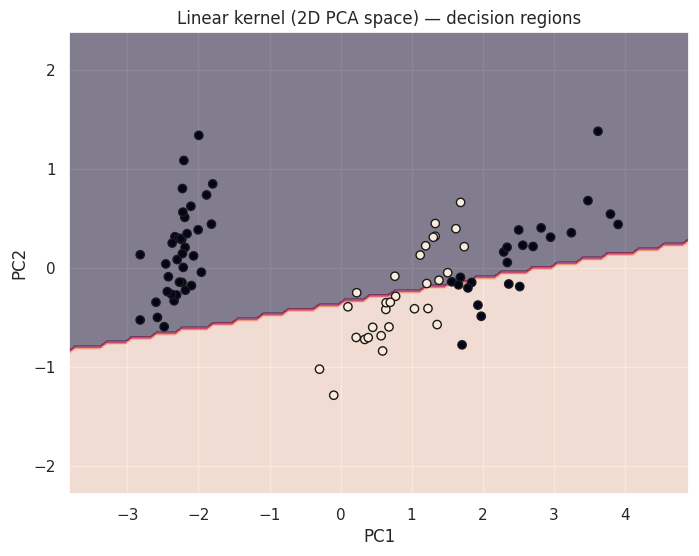

In [ ]:
# Modeling pipeline
pipe_lin = make_pipeline(StandardScaler(), PCA(n_components=2, random_state=42),
                         SVC(kernel="linear", C=1, random_state=42))
pipe_lin.fit(Xtr_nl, ytr_nl)

print("Non-linear task — Linear kernel recall:", round(recall_score(yte_nl, pipe_lin.predict(Xte_nl)), 4))

# Plotting estimators on 2D (train-only PCA space for this split)
plot_lin_nl_2d = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1, random_state=42)).fit(Xtr_nl_2d, ytr_nl)

# Decision regions (linear)
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(plot_lin_nl_2d, Xtr_nl_2d, response_method="predict", alpha=0.5, ax=ax)
ax.scatter(Xtr_nl_2d[:, 0], Xtr_nl_2d[:, 1], c=ytr_nl, edgecolor="k")
ax.set_title("Linear kernel (2D PCA space) — decision regions")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.show()

Predictably, model fails to separate classes and recall is very small. Let's try SVM with RBF kernel.

Non-linear task — RBF kernel recall: 0.85


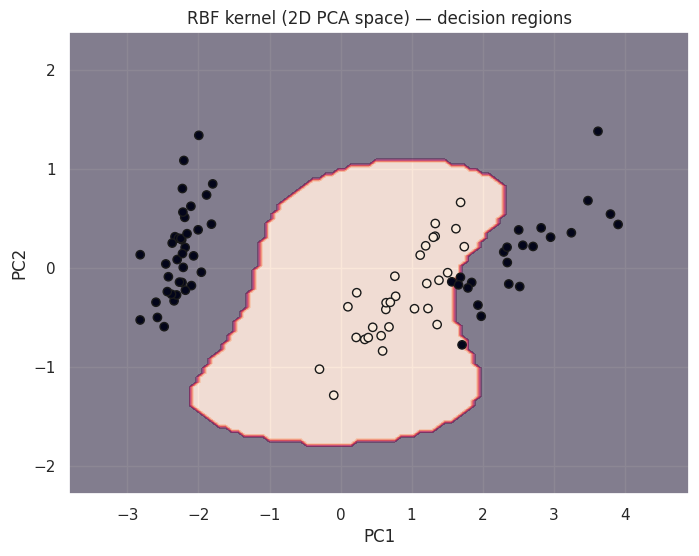

In [ ]:
# Modeling pipeline
pipe_rbf = make_pipeline(StandardScaler(), PCA(n_components=2, random_state=42),
                         SVC(kernel="rbf", C=1, random_state=42))
pipe_rbf.fit(Xtr_nl, ytr_nl)

print("Non-linear task — RBF kernel recall:",    round(recall_score(yte_nl, pipe_rbf.predict(Xte_nl)), 4))

# Plotting estimators on 2D (train-only PCA space for this split)
plot_rbf_nl_2d = make_pipeline(StandardScaler(), SVC(kernel="rbf",   C=1, random_state=42)).fit(Xtr_nl_2d, ytr_nl)

# Decision regions (RBF)
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(plot_rbf_nl_2d, Xtr_nl_2d, response_method="predict", alpha=0.5, ax=ax)
ax.scatter(Xtr_nl_2d[:, 0], Xtr_nl_2d[:, 1], c=ytr_nl, edgecolor="k")
ax.set_title("RBF kernel (2D PCA space) — decision regions")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.show()

Success! SVM manages to separate classes and get a high recall!

# SVMs with more than two classes

For multiclass classification there are two main approaches:

1) **one-versus-one** Construct SVMs, each of which compares a pair of classes. The final classification is performed by assigning the test
observation to the class to which it was most frequently assigned
2) **one-versus-all** Fit $K$ SVMs, each time comparing one of all the *K* classes to the remaining $K − 1$ classes.

In sklearn both approaches are implemented
```
decision_function_shape{‘ovo’, ‘ovr’}, default=’ovr’
```

In multi-class mode, `SVC` trains one-vs-one internally.
The parameter `decision_function_shape={'ovr','ovo'}` only affects the *output shape* of the decision function, not the training strategy (binary case ignores it).

**Now:** use original 3-class labels in 2D PCA with an RBF kernel.

In [ ]:
Xtr_mc, Xte_mc, ytr_mc, yte_mc = train_test_split(
    X_full, y_full, test_size=0.4, stratify=y_full, random_state=42
)

print("Train shape:", Xtr_mc.shape, " Test shape:", Xte_mc.shape)

Train shape: (90, 4)  Test shape: (60, 4)


In [ ]:
# Modeling pipeline on original 4D features
model_mc = make_pipeline(
    StandardScaler(),
    PCA(n_components=2, random_state=42),
    SVC(kernel="rbf", C=1, decision_function_shape="ovo", random_state=42)
)
model_mc.fit(Xtr_mc, ytr_mc)

,steps,"[('standardscaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'


In [ ]:
y_pred_model = model_mc.predict(Xte_mc)
print("Model (4D->PCA->SVC) weighted recall:",
      round(recall_score(yte_mc, y_pred_model, average="weighted"), 4))
print("\nClassification report:")
print(classification_report(yte_mc, y_pred_model, digits=4))

Model (4D->PCA->SVC) weighted recall: 0.9167

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        20
           1     0.8571    0.9000    0.8780        20
           2     0.8947    0.8500    0.8718        20

    accuracy                         0.9167        60
   macro avg     0.9173    0.9167    0.9166        60
weighted avg     0.9173    0.9167    0.9166        60



Recall is high, classes are well-separated!

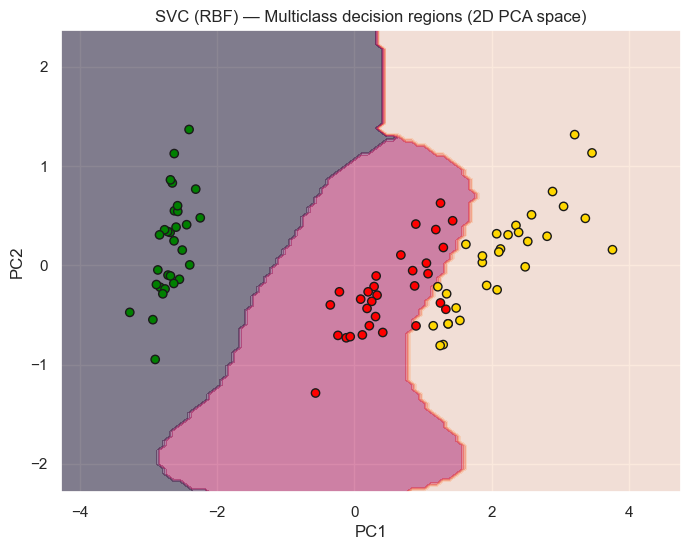

In [ ]:
# Separate estimator ONLY for plotting in 2D PCA space
pca_viz = PCA(n_components=2, random_state=42)
X_tr_2d_mc = pca_viz.fit_transform(Xtr_mc)
X_te_2d_mc = pca_viz.transform(Xte_mc)

plot_est = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1, decision_function_shape="ovo", random_state=42)
).fit(X_tr_2d_mc, ytr_mc)

# Decision boundary in the 2D PCA space
palette_mc = {0: "green", 1: "red", 2: "gold"}
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    plot_est, X_tr_2d_mc, response_method="predict", alpha=0.5, ax=ax
)
ax.scatter(X_tr_2d_mc[:, 0], X_tr_2d_mc[:, 1], c=[palette_mc[i] for i in ytr_mc], edgecolor="k")
ax.set_title("SVC (RBF) — Multiclass decision regions (2D PCA space)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.show()